# Aprendizaje por diferencia temporal (TD)

En este ejercicio vamos a implementar el método de diferencia temporal para para resolver MDPs con transiciones y recompensas desconocidas. 

El método de TD se basa en el cálculo de los valores para los estados de acuerdo con la fórmula:

$V^\pi(s) \leftarrow (1-\alpha)V^\pi(s) + \alpha[R(s, \pi(s), s') + \gamma V^\pi(s')]$

donde $\alpha$ corresponde a la taza de aprendizaje.

#### Task 1

Para implementar TD definimos `td_learning.py` como una extensión del ambiente de Gridworld. Dentro de esta extensión debemos asegurarnos que:
  - Seguimos una política, dada como un parámetro del ambiente.
  - Cada paso de la muestra ejecuta la política para el estado actual, obteniendo un estado de llegada y una recompensa. Tenga en cuenta que las acciones no son determinísticas y la ejecución de cada acción depende de un factor de ruido (en el caso de Gridworld, tomaremos un factor de ruido de 0.2 para las acciones abajo e izquierda y 0.3 para las acciones arriba y derecha, desconocida para el agente). Por ejemplo, el agente tiene una probabilidad de 0.8 de moverse a la izquierda y abajo y terminar en el estado correspondiente y probabilidad de 0.2 de terminar en cualquiera de las otras tres direcciones.
  - A partir de los valores obtenidos de diferentes muestras, obtenga una nueva política.
  - Utilice una taza de aprendizaje de `0.7`

Responda las preguntas
1. ¿Cuántas iteraciones son necesarias para que la política de las muestras se estabilice?
2. ¿Cómo se compara la política obtenida con la calculada utilizando iteración de valores o iteración de políticas? ¿Existe alguna diferencia? ¿Porqué?



## Solución


In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
from environment import Environment
from td_learning import TDLearning

ACTION_SYMBOLS = {"up": "↑", "down": "↓", "left": "←", "right": "→", "exit": "◉"}


def make_initial_policy(env):
    policy = {}
    for i in range(env.nrows):
        for j in range(env.ncols):
            state = (i, j)
            actions = env.get_posible_actions(state)
            if actions:
                policy[state] = np.random.choice(actions)
    return policy


def plot_policy(env, policy, values, title):
    cell_size = 1.5 if max(env.nrows, env.ncols) <= 6 else 1.1
    font_size = 10 if max(env.nrows, env.ncols) <= 6 else 7

    fig, ax = plt.subplots(figsize=(env.ncols * cell_size, env.nrows * cell_size))

    value_matrix = np.zeros((env.nrows, env.ncols))
    for (i, j), v in values.items():
        value_matrix[i, j] = v

    im = ax.imshow(value_matrix, cmap="RdYlGn", aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.8, label="V(s)")

    for i in range(env.nrows):
        for j in range(env.ncols):
            cell = env.board[i][j]
            if cell == env.PROHIBITED_CELL:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="black", zorder=2))
                continue
            symbol = ACTION_SYMBOLS.get(policy.get((i, j)), "·")
            v = value_matrix[i, j]
            ax.text(j, i, f"{symbol}\n{v:.2f}", ha="center", va="center", fontsize=font_size, zorder=3)

    ax.set_xticks(np.arange(-0.5, env.ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.nrows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


In [7]:
grid_board = [
    [" ", " ", " ", "+1"],
    [" ", "#", " ", "-1"],
    ["S", " ", " ", " "],
]

env_small = Environment(grid_board)
print(f"Gridworld: {env_small.nrows}x{env_small.ncols}, estado inicial: {env_small.initial_state}")

np.random.seed(42)
initial_policy_small = make_initial_policy(env_small)
td_small = TDLearning(env_small, initial_policy_small)
iterations_small = td_small.run(episodes_per_step=500)

print(f"Política estabilizada en {iterations_small} iteraciones de política ({iterations_small * 500} episodios totales)")


Gridworld: 3x4, estado inicial: (2, 0)
Iteración 10, política: {(0, 0): 'right', (0, 1): 'right', (0, 2): 'right', (0, 3): 'exit', (1, 0): 'up', (1, 2): 'up', (1, 3): 'exit', (2, 0): 'up', (2, 1): 'right', (2, 2): 'up', (2, 3): 'left'}
Iteración 20, política: {(0, 0): 'right', (0, 1): 'right', (0, 2): 'right', (0, 3): 'exit', (1, 0): 'up', (1, 2): 'up', (1, 3): 'exit', (2, 0): 'up', (2, 1): 'left', (2, 2): 'up', (2, 3): 'left'}
Iteración 30, política: {(0, 0): 'right', (0, 1): 'right', (0, 2): 'right', (0, 3): 'exit', (1, 0): 'up', (1, 2): 'up', (1, 3): 'exit', (2, 0): 'down', (2, 1): 'right', (2, 2): 'up', (2, 3): 'left'}
Iteración 40, política: {(0, 0): 'right', (0, 1): 'right', (0, 2): 'right', (0, 3): 'exit', (1, 0): 'up', (1, 2): 'up', (1, 3): 'exit', (2, 0): 'up', (2, 1): 'left', (2, 2): 'up', (2, 3): 'down'}
Iteración 50, política: {(0, 0): 'right', (0, 1): 'right', (0, 2): 'right', (0, 3): 'exit', (1, 0): 'up', (1, 2): 'up', (1, 3): 'exit', (2, 0): 'up', (2, 1): 'left', (2, 2):

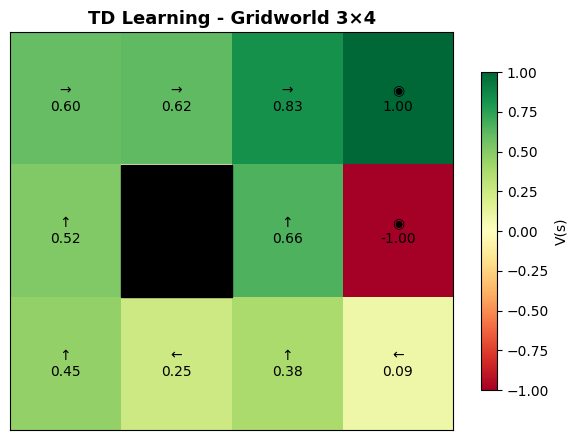

In [8]:
plot_policy(env_small, td_small.policy, td_small.values, "TD Learning - Gridworld 3×4")


In [2]:
grid_board_big = [
    ["S", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    [" ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    [" ", "#", "#", "#", "#", " ", "#", "#", "#", " "],
    [" ", " ", " ", " ", "#", " ", " ", " ", " ", " "],
    [" ", " ", " ", " ", "#", "-1", " ", " ", " ", " "],
    [" ", " ", " ", " ", "#", "1", " ", " ", " ", " "],
    [" ", " ", " ", " ", "#", " ", " ", " ", " ", " "],
    [" ", " ", " ", " ", "#", "-1", "-1", " ", " ", " "],
    [" ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    [" ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
]

env_big = Environment(grid_board_big)
print(f"Gridworld: {env_big.nrows}x{env_big.ncols}, estado inicial: {env_big.initial_state}")

np.random.seed(72)
initial_policy_big = make_initial_policy(env_big)
td_big = TDLearning(env_big, initial_policy_big, gamma=0.995)
iterations_big = td_big.run(episodes_per_step=1_000, max_steps=10_000, max_iterations=100)

print(f"Política estabilizada en {iterations_big} iteraciones de política ({iterations_big * 1_000} episodios totales)")


Gridworld: 10x10, estado inicial: (0, 0)


KeyboardInterrupt: 

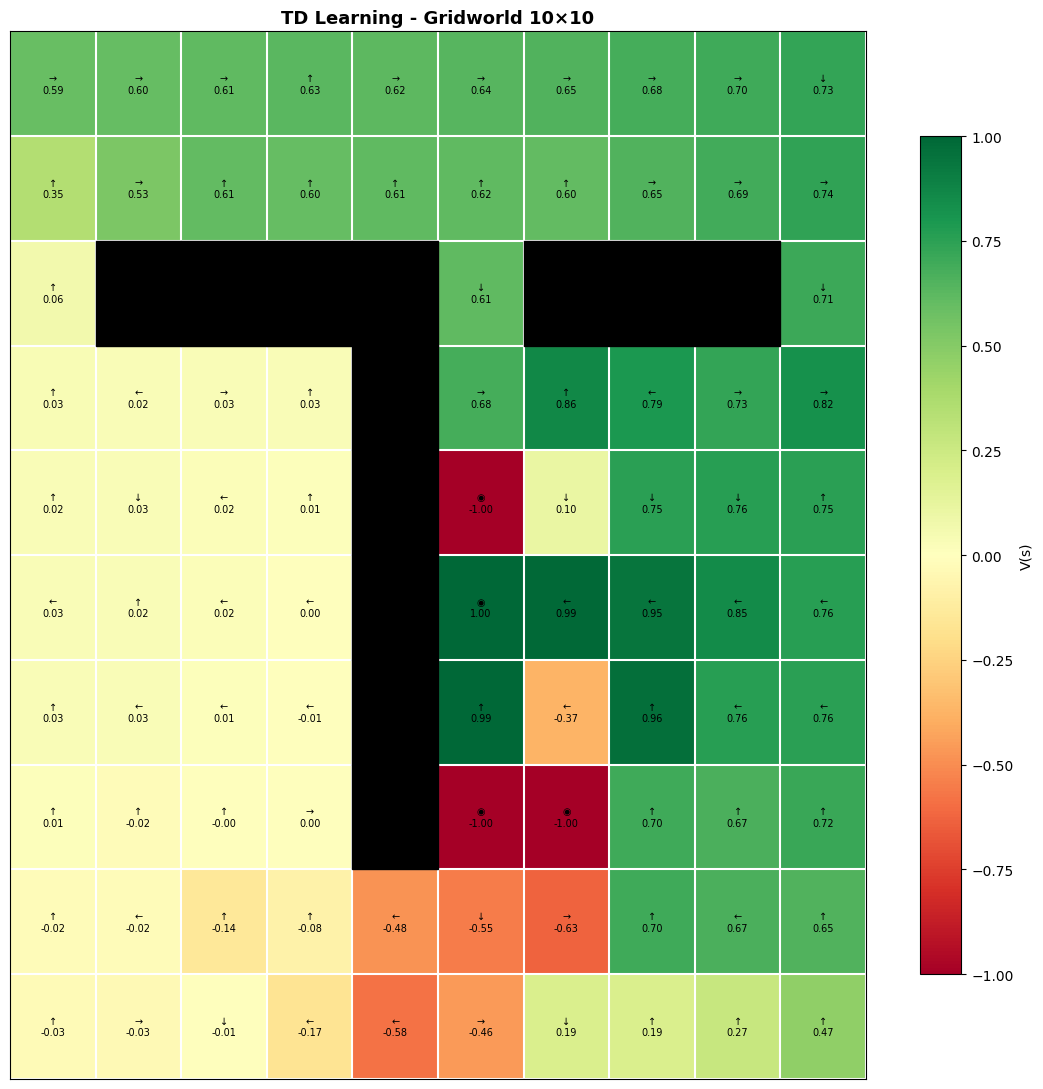

In [17]:
plot_policy(env_big, td_big.policy, td_big.values, "TD Learning - Gridworld 10×10")

In [ ]:
grid_board_cliff = [
    ["-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1"],
    ["-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1"],
    ["-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1"],
    ["-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1", "-1"],
    ["S", "-100", "-100", "-100", "-100", "-100", "-100", "-100", "-100", "1"],
]

env_cliff = Environment(grid_board_cliff)
print(f"Gridworld: Cliff, estado inicial: {env_cliff.initial_state}")

np.random.seed(86)
initial_policy_cliff = make_initial_policy(env_cliff)
td_cliff = TDLearning(env_cliff, initial_policy_cliff, gamma=0.95)
iterations_cliff = td_cliff.run(episodes_per_step=1_000, max_iterations=1_000)

print(f"Política estabilizada en {iterations_cliff} iteraciones de política ({iterations_cliff * 1_000} episodios totales)")


Gridworld: Cliff, estado inicial: (4, 0)
Iteración 10, política: {(0, 0): 'right', (0, 1): 'right', (0, 2): 'right', (0, 3): 'right', (0, 4): 'right', (0, 5): 'up', (0, 6): 'right', (0, 7): 'right', (0, 8): 'right', (0, 9): 'down', (1, 0): 'up', (1, 1): 'up', (1, 2): 'up', (1, 3): 'right', (1, 4): 'up', (1, 5): 'up', (1, 6): 'right', (1, 7): 'right', (1, 8): 'down', (1, 9): 'down', (2, 0): 'up', (2, 1): 'down', (2, 2): 'up', (2, 3): 'right', (2, 4): 'up', (2, 5): 'left', (2, 6): 'up', (2, 7): 'right', (2, 8): 'right', (2, 9): 'down', (3, 0): 'right', (3, 1): 'left', (3, 2): 'left', (3, 3): 'up', (3, 4): 'up', (3, 5): 'up', (3, 6): 'up', (3, 7): 'up', (3, 8): 'right', (3, 9): 'down', (4, 0): 'up', (4, 1): 'exit', (4, 2): 'exit', (4, 3): 'exit', (4, 4): 'exit', (4, 5): 'exit', (4, 6): 'exit', (4, 7): 'exit', (4, 8): 'exit', (4, 9): 'exit'}
Iteración 20, política: {(0, 0): 'up', (0, 1): 'down', (0, 2): 'right', (0, 3): 'up', (0, 4): 'left', (0, 5): 'right', (0, 6): 'right', (0, 7): 'right

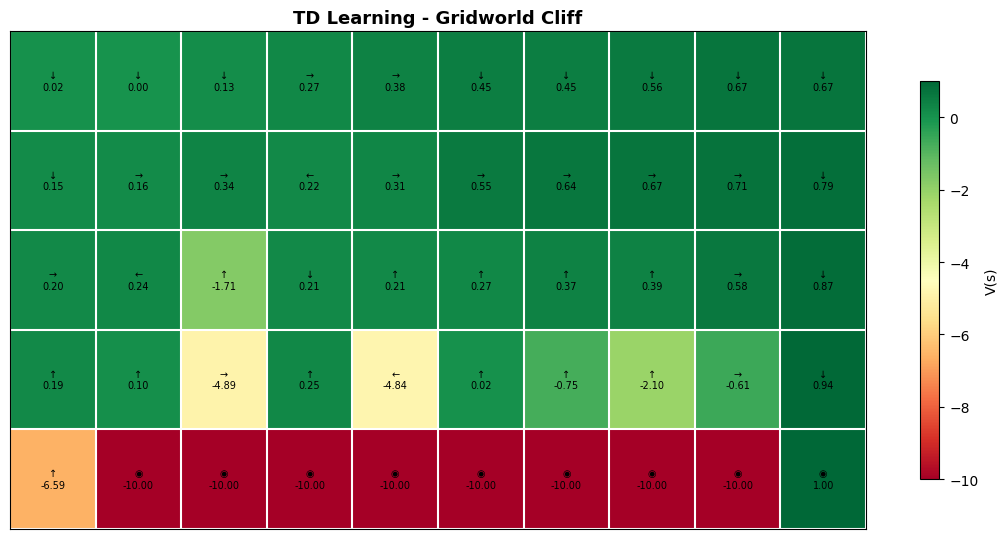

In [18]:
plot_policy(env_cliff, td_cliff.policy, td_cliff.values, "TD Learning - Gridworld Cliff")

## Respuestas

### 1. ¿Cuántas iteraciones son necesarias para que la política se estabilice?

**Gridworld 3×4:** la política se estabilizó en pocas iteraciones de mejora de política (cada una con 500 episodios). En nuestro caso con 64 iteraciones fue suficiente para la convergencia. Para este ambiente pequeño el algoritmo converge rápidamente porque la mayoría de trayectorias alcanzan los estados terminales en menos de 10 pasos, lo que proporciona señales de recompensa frecuentes.

**Gridworld 10×10:** requiere más iteraciones (con 1 000 episodios cada una) debido a que el espacio de estados es mayor y las trayectorias hasta los terminales son más largas. El ruido estocástico también tiene más oportunidades de acumular varianza antes de llegar a la recompensa.
Debido a esto, tuve que aumentar el gamma a 0.995 para que el agente valore más las recompensas futuras y así estabilizar la política en algún momento. No obstante, lo dejé como máximo en 100 iteraciones de política, ya que por lo que observé mientras no tenía límite, era que el agente esta haciendo un bucle entre varias opciones de política sin estabilizarse, probablemente por el ruido estocástico que hace que el agente no pueda decidir entre varias opciones de política que parecen similares.

**Gridworld Cliff:** este ambiente es más difícil debido a la gran penalización de -10 por caer en el acantilado. Con gamma=0.95, la política se estabilizó no se estabiliza (con 1 000 episodios cada una). El agente aprende rápidamente a evitar el acantilado, incluso decide alejarse del acantilado para evitar caer con él. También le aumenté el gamma a 0.95 para poder propagar los valores hasta el inicio.

---

### 2. ¿Cómo se compara la política con la de iteración de valores / iteración de políticas?

Ambas políticas convergen a **la misma política óptima** (o una equivalente) para este Gridworld. Sin embargo, existen diferencias metodológicas importantes:

| Aspecto | VI / PI | TD  |
|---|---|---|
| Conocimiento del modelo | Requiere $P(s'\|s,a)$ y $R(s,a,s')$ exactas | No necesita el modelo |
| Fuente de valores | Cálculo directo sobre el MDP completo | Muestras estocásticas de episodios |
| Actualización | Barrido completo de todos los estados | Un paso por transición observada |
| Ruido en estimación | Ninguno, ya que el valor sólo es afectado por el modelo| Varianza estadística reducida por α |

**¿Por qué puede haber diferencias?** En TD, la estimación de la política óptima se deriva de $V^\pi(s)$ aprendidos con $\alpha = 0.7$. La mejora de política usa la transición determinista predicha, lo que puede producir diferencias en estados donde el ruido cambia cuál celda vecina es realmente más valiosa. Con suficientes episodios estas diferencias desaparecen, ya que los valores deberían convergen a $V^*(s)$ independientemente del ruido de muestreo. No obstante, la proporción del ruido puede hacer que este tiempo sea demasiado alto, y en algunos casos, puede que los agentes no se estabilicen en su totalidad en un tiempo razonable.
